# Nama  : Dhini Ari Minarti
# NIM   : 4222311022
# Kelas : Robotika A Malam

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [52]:
df = pd.read_csv('WineQT.csv')
df.head(10)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


## EDA

Text(0.5, 1.0, 'Sebaran Nilai alcohol vs quality')

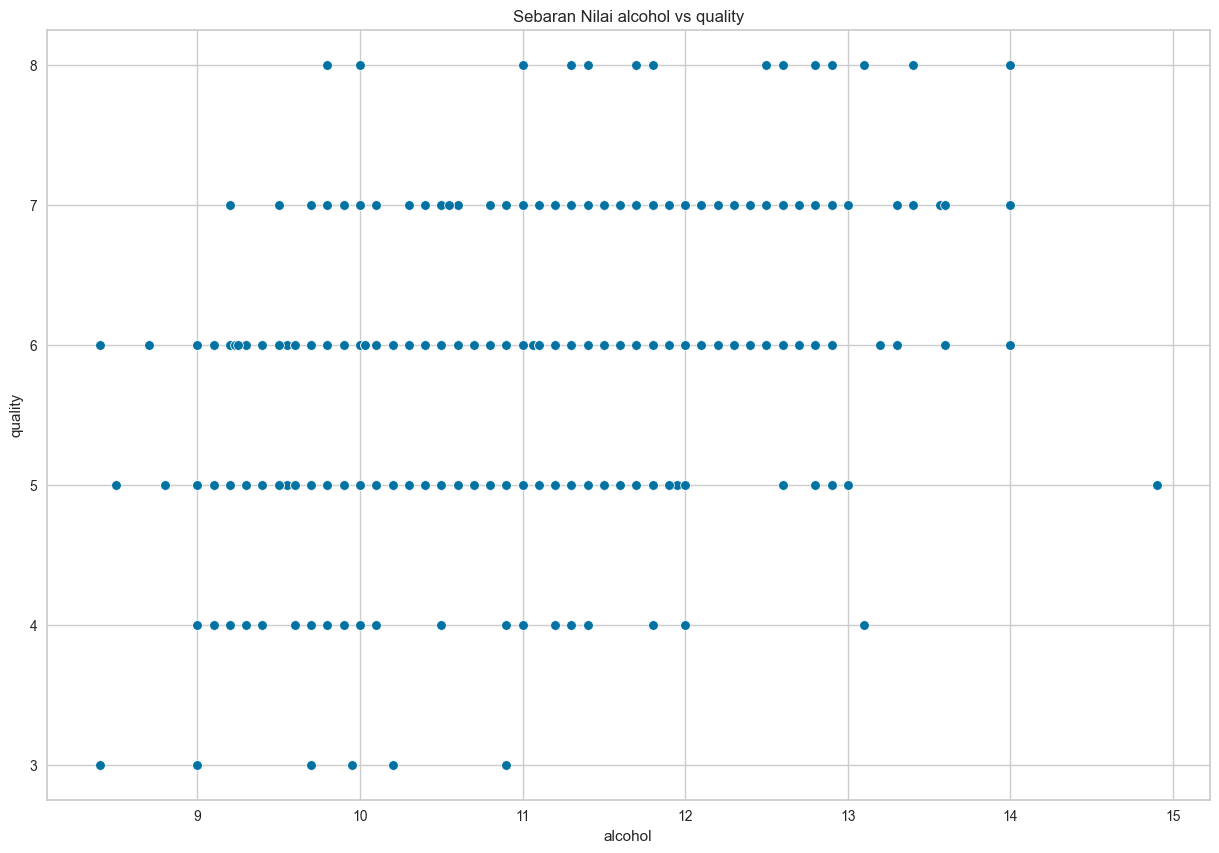

In [29]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality')
plt.title('Sebaran Nilai alcohol vs quality')

In [30]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


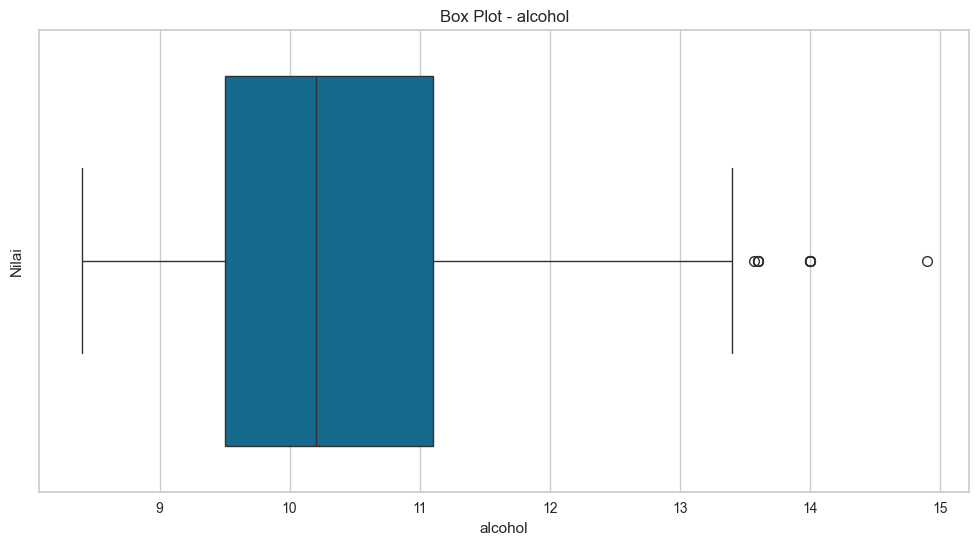

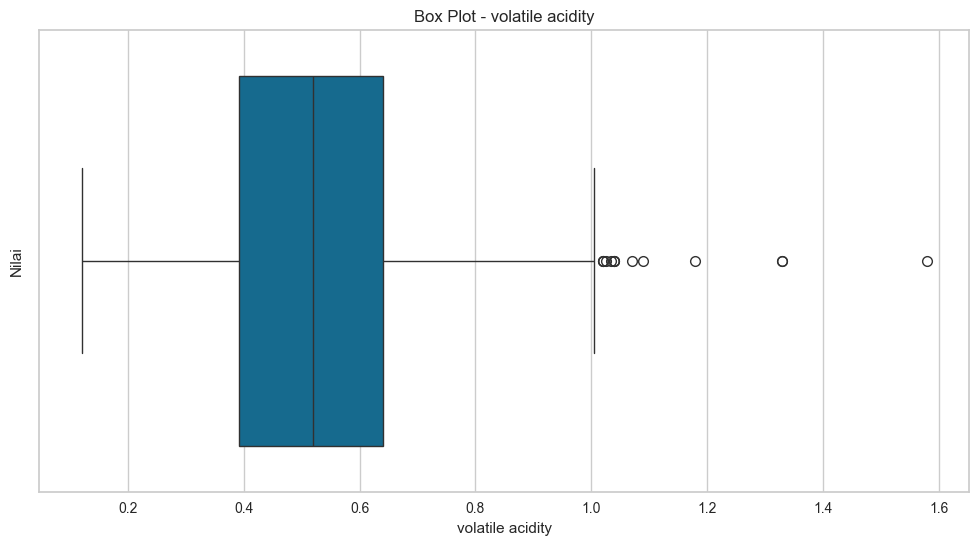

In [31]:
columns = ['alcohol', 'volatile acidity']

for col in columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

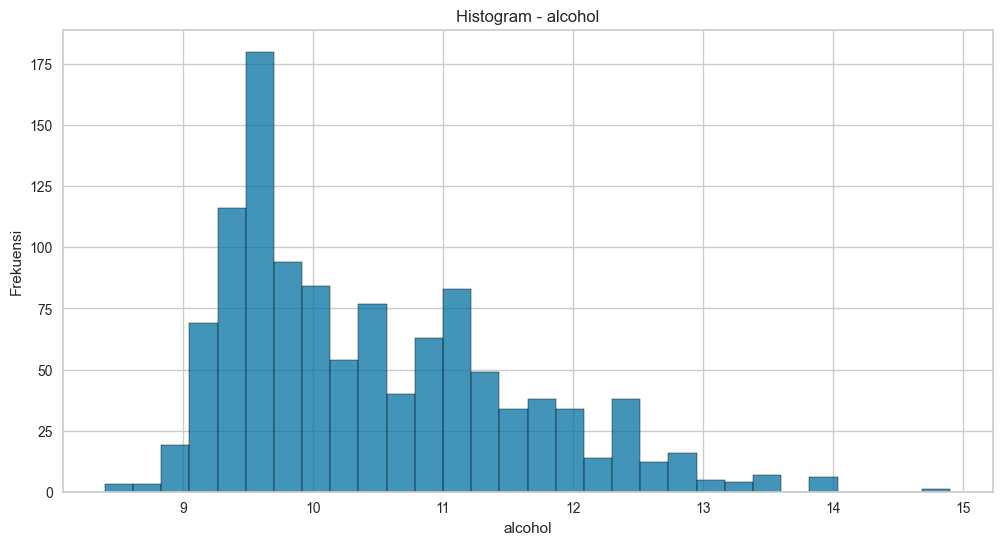

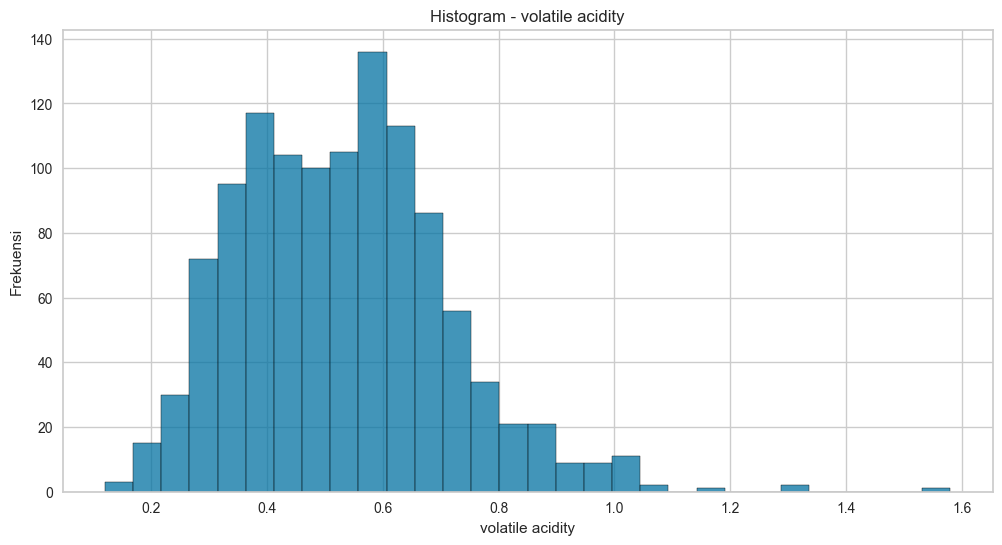

In [32]:
for col in columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional) -> pada step ini tidak perlu, karena nilai fitur masih wajar
3. Feature Scalling

In [33]:
print(f"Dataframe dimension before duplication drop {df.shape[0]}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


Berdasarkan output di atas, tidak ditemukan baris data yang terduplikasi pada dataset ini.

In [34]:
fitur_columns = ['alcohol', 'volatile acidity']
X = df[fitur_columns].values
y = df['quality'].values  

In [35]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns)
df_scalling.describe()

,alcohol,volatile acidity
count,1.143000e+03,1.143000e+03
mean,-1.193563e-15,4.475860e-16
std,1.000438e+00,1.000438e+00
min,-1.887834e+00,-2.290883e+00
25%,-8.709366e-01,-7.732388e-01
50%,-2.238203e-01,-6.314838e-02
75%,6.081863e-01,6.051720e-01
max,4.121103e+00,5.840349e+00


In [36]:
X_std

array([[-0.96338181,  0.93933222],
       [-0.59360107,  1.94181282],
       [-0.59360107,  1.27349242],
       ...,
       [ 0.05351522,  0.38239855],
       [ 0.70063152,  0.10393172],
       [-0.22382033,  0.6330187 ]], shape=(1143, 2))

In [37]:
df_scalling

,alcohol,volatile acidity
0,-0.963382,0.939332
1,-0.593601,1.941813
2,-0.593601,1.273492
3,-0.593601,-1.399789
4,-0.963382,0.939332
...,...,...
1138,0.515741,-0.118842
1139,-0.870937,0.493785
1140,0.053515,0.382399
1141,0.700632,0.103932


## TO DO!
- Lengkapi kode di bawah ini untuk menampilkan perbandingan distribusi fitur sebelum dan sesudah proses feature scaling menggunakan StandardScaler

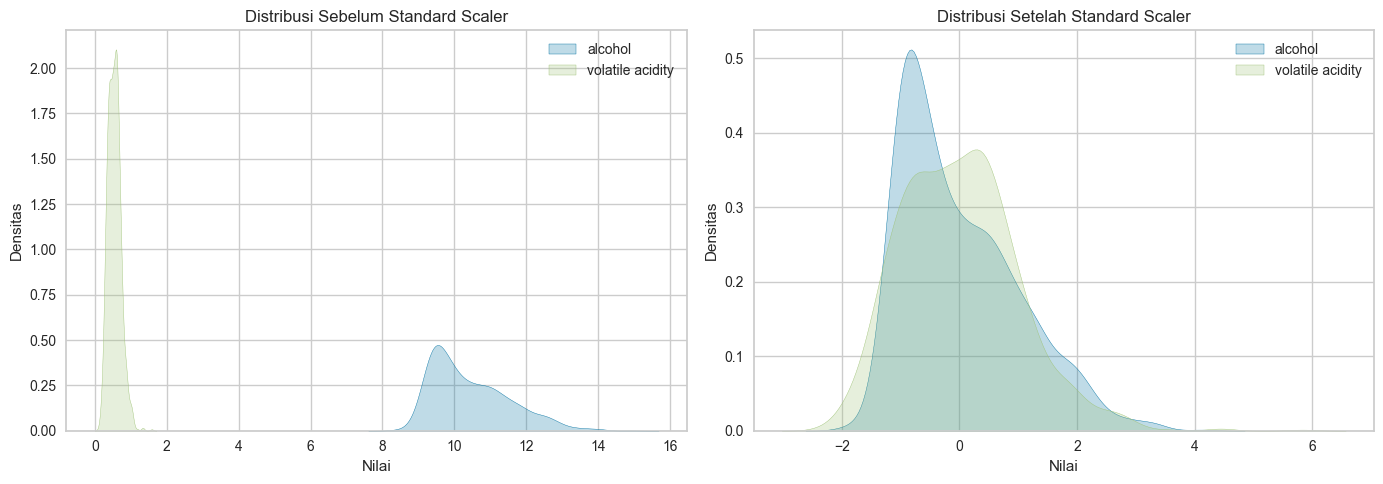

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

for col in fitur_columns:
    sns.kdeplot(df[col].values, ax=axes[0], fill=True, label=col)
axes[0].set_title('Distribusi Sebelum Standard Scaler')
axes[0].set_xlabel('Nilai')
axes[0].set_ylabel('Densitas')
axes[0].legend()

for col in fitur_columns:
    sns.kdeplot(df_scalling[col].values, ax=axes[1], fill=True, label=col)
axes[1].set_title('Distribusi Setelah Standard Scaler')
axes[1].set_xlabel('Nilai')
axes[1].set_ylabel('Densitas')
axes[1].legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Sebelum scaling, distribusi fitur `alcohol` dan `volatile acidity` memiliki rentang nilai yang jauh berbeda, sehingga fitur dengan skala lebih besar akan mendominasi perhitungan jarak pada K-Means.
2. Setelah dilakukan StandardScaler, kedua fitur bertransformasi menjadi distribusi dengan rata-rata 0 dan standar deviasi 1, sehingga bobot masing-masing fitur menjadi seimbang dalam proses clustering.

## K-means Clustering
Pada bagian ini akan diuji dua pendekatan untuk menentukan jumlah cluster (K) yang paling optimal, yaitu:
1. Metode Elbow
2. Via-Score Plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

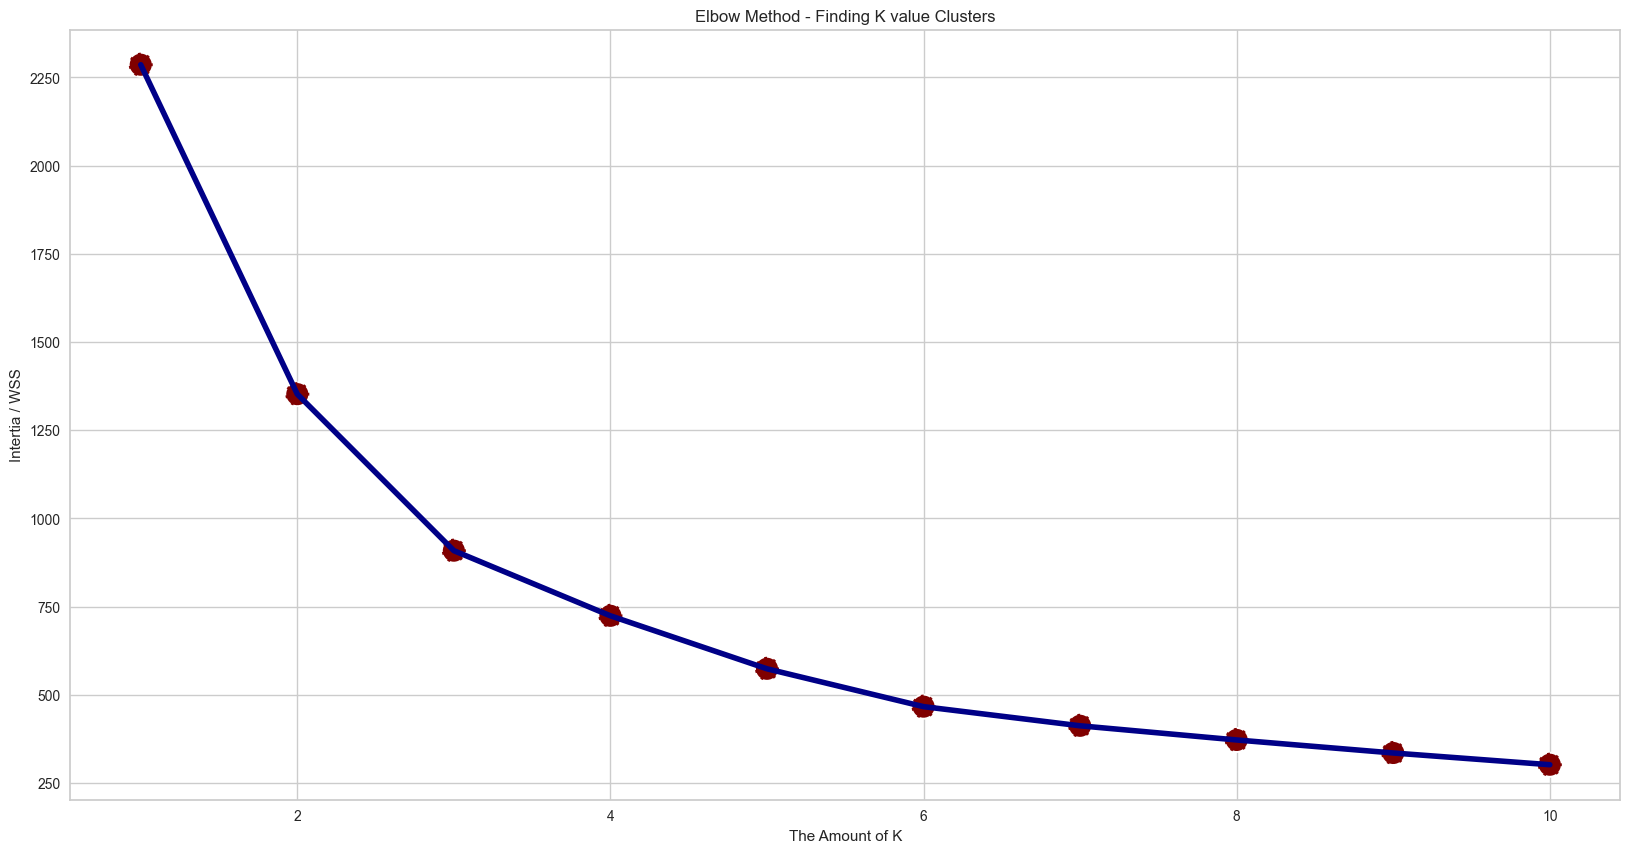

In [39]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [40]:
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [41]:
df['cluster_elbow'] = kmeans_elbow.labels_

In [42]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,0
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,0
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1


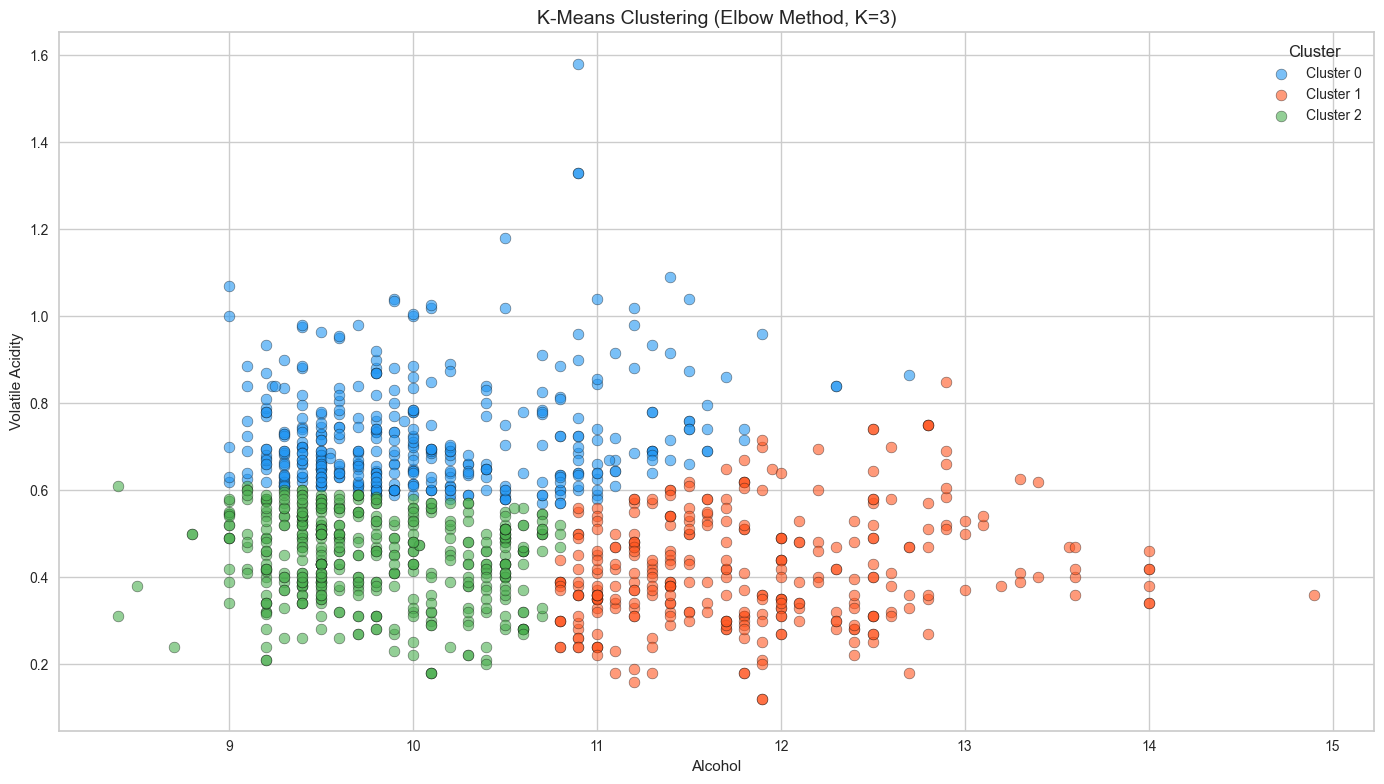

In [43]:
fig, ax = plt.subplots(figsize=(14, 8))
palette = {0: '#2196F3', 1: '#FF5722', 2: '#4CAF50'}
for cluster_id in sorted(df['cluster_elbow'].unique()):
    subset = df[df['cluster_elbow'] == cluster_id]
    ax.scatter(subset['alcohol'], subset['volatile acidity'],
               label=f'Cluster {cluster_id}',
               color=palette[cluster_id], alpha=0.6, edgecolors='k', linewidths=0.4, s=60)
ax.set_title('K-Means Clustering (Elbow Method, K=3)', fontsize=14)
ax.set_xlabel('Alcohol')
ax.set_ylabel('Volatile Acidity')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

### Bandingkan hasil dengan label anotator

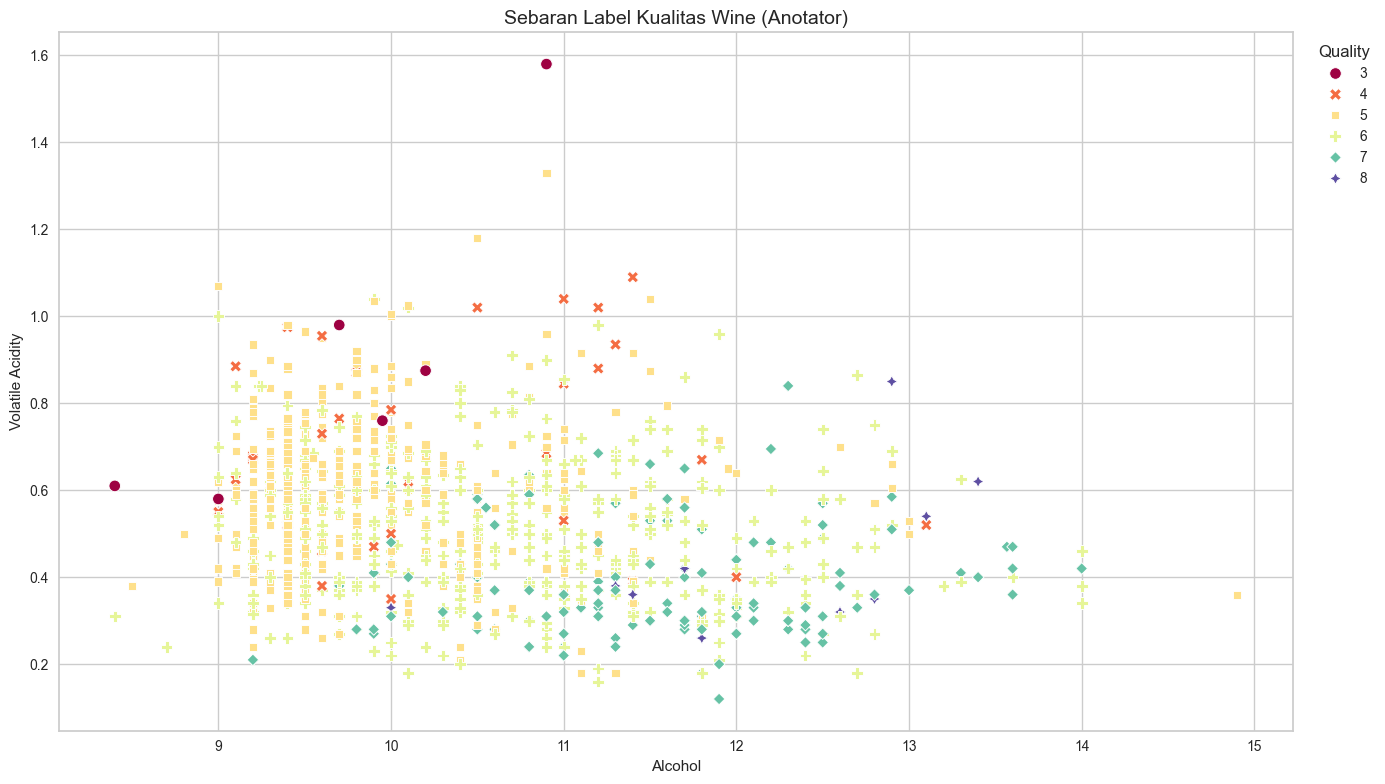

In [44]:
fig, ax = plt.subplots(figsize=(14, 8))
quality_palette = sns.color_palette('Spectral', n_colors=df['quality'].nunique())
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='quality',
                palette='Spectral', style='quality', markers=True, s=70, ax=ax)
ax.set_title('Sebaran Label Kualitas Wine (Anotator)', fontsize=14)
ax.set_xlabel('Alcohol')
ax.set_ylabel('Volatile Acidity')
ax.legend(title='Quality', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Hasil clustering menggunakan metode Elbow terbilang cukup representatif, karena pembagian klaster mendekati distribusi label quality dari anotator. Berikut pemetaannya:
1. Cluster 0 → Kualitas Rendah (Low Quality)
2. Cluster 1 → Kualitas Sedang (Medium Quality)
3. Cluster 2 → Kualitas Tinggi (High Quality)

### 2. Via Score Plot

In [45]:
!pip install yellowbrick


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


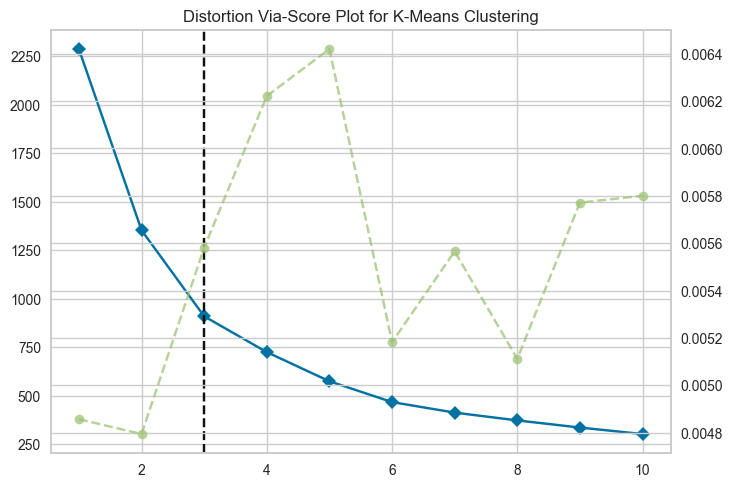

In [46]:
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans(random_state=0)
k_means_via._estimator_type = 'clusterer'

visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)     
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [47]:
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=4, random_state=0)
kmeans_via.fit(df_scalling.values)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [48]:
df['cluster_via'] = kmeans_via.labels_

In [49]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,0,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,0,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,0,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,0,0
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,0,0
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1,3


## TO DO !
- Lakukan visualisasi hasil clustering K-Means menggunakan nilai K yang diperoleh dari Via Score Plot, kemudian bandingkan hasilnya dengan label anotator

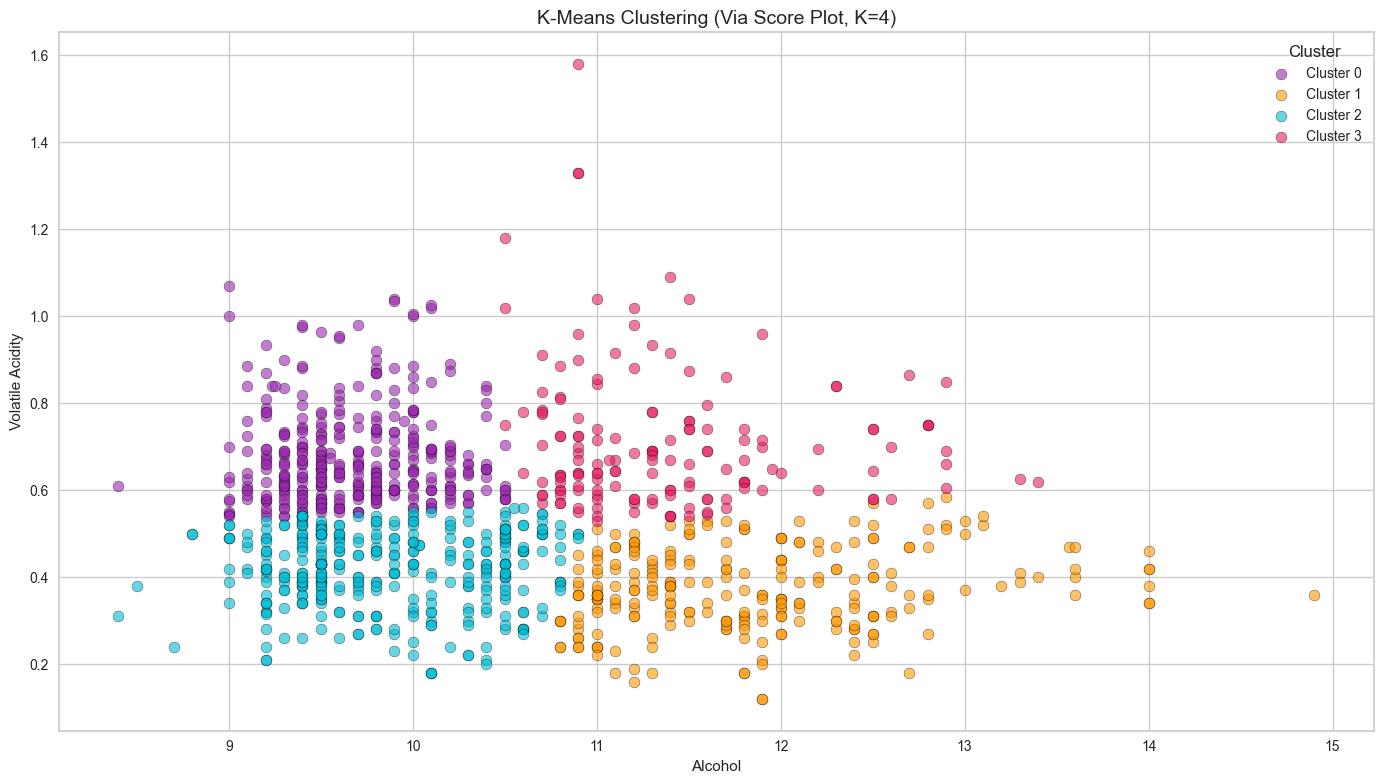

In [50]:
fig, ax = plt.subplots(figsize=(14, 8))
cluster_colors = {0: '#9C27B0', 1: '#FF9800', 2: '#00BCD4', 3: '#E91E63'}
for cluster_id in sorted(df['cluster_via'].unique()):
    subset = df[df['cluster_via'] == cluster_id]
    ax.scatter(subset['alcohol'], subset['volatile acidity'],
               label=f'Cluster {cluster_id}',
               color=cluster_colors[cluster_id], alpha=0.6, edgecolors='k', linewidths=0.4, s=60)
ax.set_title('K-Means Clustering (Via Score Plot, K=4)', fontsize=14)
ax.set_xlabel('Alcohol')
ax.set_ylabel('Volatile Acidity')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

### Bandingkan dengan label anotator

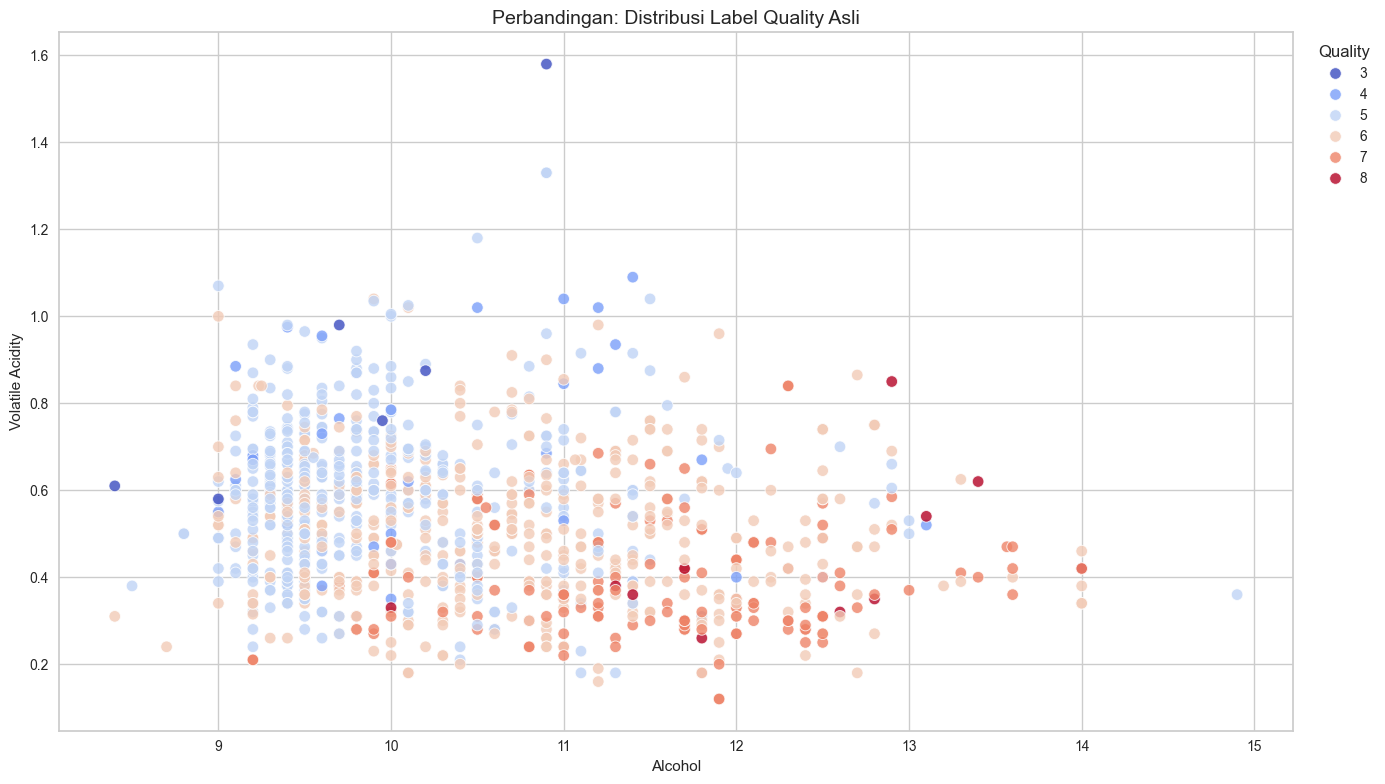

In [51]:
fig, ax = plt.subplots(figsize=(14, 8))
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='quality',
                palette='coolwarm', s=70, alpha=0.8, ax=ax)
ax.set_title('Perbandingan: Distribusi Label Quality Asli', fontsize=14)
ax.set_xlabel('Alcohol')
ax.set_ylabel('Volatile Acidity')
ax.legend(title='Quality', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Metode Via Score Plot menghasilkan nilai K=4 sebagai jumlah klaster yang paling optimal berdasarkan skor distorsi yang dihitung secara otomatis.
2. Dibandingkan dengan label quality asli, hasil clustering K=4 memberikan pemisahan yang lebih granular. Meskipun tidak sepenuhnya identik karena label quality memiliki 6 kategori, pola distribusi antar klaster cukup mencerminkan tingkat kualitas wine.

### Thank you :)